In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from opacus import PrivacyEngine
import gc
import numpy as np
import torch.nn.functional as F


transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),  
])

mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(dataset=mnist_dataset, batch_size=64, shuffle=True)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.ToTensor(),                       
])

cifar_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)

cifar_test_data = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=cifar_test_data, batch_size=64, shuffle=False)

private_subset = cifar_dataset

np.random.seed(42)
mnist_indices = np.random.choice(len(mnist_dataset), size=2000, replace=False)
public_subset = Subset(mnist_dataset, mnist_indices)

train_loader_private = DataLoader(dataset=private_subset, batch_size=64, shuffle=True)
train_loader_public = DataLoader(dataset=public_subset, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.23MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.61MB/s]


In [2]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(480, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 480)
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x
    
model = Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# privacy_engine = PrivacyEngine()

gc.collect()

0

In [3]:
epochs_1 = 5
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
for epoch in range(epochs_1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_public:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/{epochs_1}]')
    print("Training loss", (running_loss / total))  
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

Epoch [1/5]
Training loss 2.2864360656738283
Training accuracy 14.6 %
Testing loss 0.4572872131347656
Testing accuracy 10.96 %
Epoch [2/5]
Training loss 2.1273586330413816
Training accuracy 48.65 %
Testing loss 0.42547172660827637
Testing accuracy 10.66 %
Epoch [3/5]
Training loss 1.3256992564201355
Training accuracy 66.5 %
Testing loss 0.2651398512840271
Testing accuracy 10.88 %
Epoch [4/5]
Training loss 0.6926861071586609
Training accuracy 81.05 %
Testing loss 0.13853722143173217
Testing accuracy 10.15 %
Epoch [5/5]
Training loss 0.5108907618522645
Training accuracy 86.65 %
Testing loss 0.10217815237045288
Testing accuracy 10.17 %


In [4]:
epochs_2 = 10
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
target_delta = 1e-5
# model, optimizer, train_loader_private = privacy_engine.make_private_with_epsilon(
#     module=model,
#     optimizer=optimizer,
#     data_loader=train_loader_private,
#     epochs=10,
#     target_epsilon=3,
#     target_delta=target_delta,
#     max_grad_norm=0.1,
# )
for epoch in range(epochs_2):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader_private:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/{epochs_2}]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()

    # epsilon = privacy_engine.get_epsilon(delta=target_delta)
    # print(f"Privacy Budget (epsilon, delta): ({epsilon:.2f}, {target_delta})")

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")


Epoch [1/10]
Training loss 2.0885403312683106
Training accuracy 23.498 %
Testing loss 10.442701656341553
Testing accuracy 30.48 %
Epoch [2/10]
Training loss 1.7774791624450683
Training accuracy 36.022 %
Testing loss 8.887395812225341
Testing accuracy 38.51 %
Epoch [3/10]
Training loss 1.639042622871399
Training accuracy 41.306 %
Testing loss 8.195213114356994
Testing accuracy 41.8 %
Epoch [4/10]
Training loss 1.5461643658065796
Training accuracy 44.946 %
Testing loss 7.730821829032898
Testing accuracy 44.76 %
Epoch [5/10]
Training loss 1.4802401819992066
Training accuracy 47.338 %
Testing loss 7.4012009099960325
Testing accuracy 47.2 %
Epoch [6/10]
Training loss 1.417663833770752
Training accuracy 49.674 %
Testing loss 7.08831916885376
Testing accuracy 48.57 %
Epoch [7/10]
Training loss 1.356674726333618
Training accuracy 51.662 %
Testing loss 6.783373631668091
Testing accuracy 49.57 %
Epoch [8/10]
Training loss 1.3101330883789062
Training accuracy 53.622 %
Testing loss 6.5506654418945

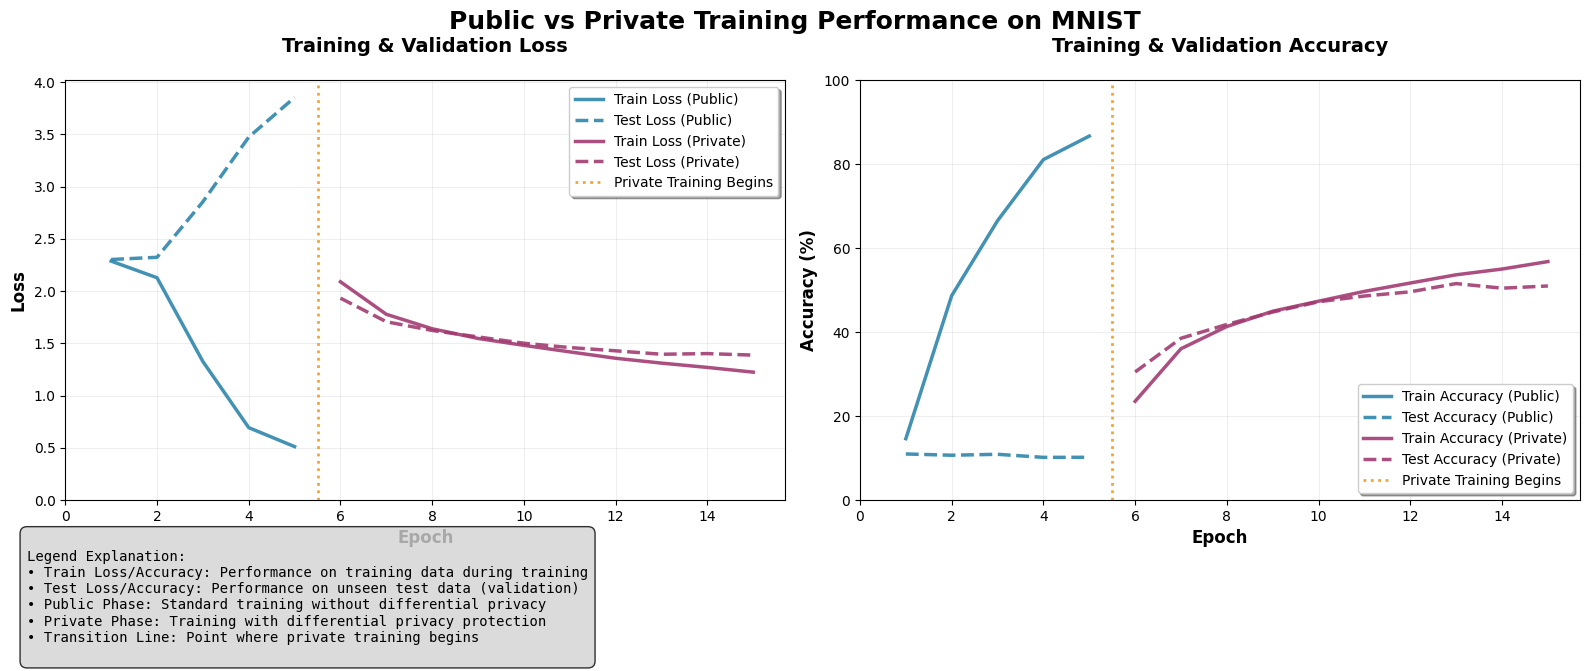

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Combine loss and accuracy for plotting
full_train_losses = train_losses + train_losses_2
full_test_losses = test_losses + test_losses_2
full_train_accuracies = train_accuracies + train_accuracies_2
full_test_accuracies = test_accuracies + test_accuracies_2

# Create epoch ranges
public_epochs = list(range(1, epochs_1 + 1))
private_epochs = list(range(epochs_1 + 1, epochs_1 + epochs_2 + 1))

# Set up the figure with improved styling
plt.rcParams.update({'font.size': 10})  # Set default font size
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define colors for consistency
public_color = '#2E86AB'    # Blue
private_color = '#A23B72'   # Red/Purple
transition_color = '#F18F01' # Orange

# --- Loss Plot ---
ax1.plot(public_epochs, train_losses, color=public_color, linewidth=2.5, 
         label='Train Loss (Public)', alpha=0.9)
ax1.plot(public_epochs, test_losses, color=public_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Public)', alpha=0.9)

ax1.plot(private_epochs, train_losses_2, color=private_color, linewidth=2.5, 
         label='Train Loss (Private)', alpha=0.9)
ax1.plot(private_epochs, test_losses_2, color=private_color, linewidth=2.5, 
         linestyle='--', label='Test Loss (Private)', alpha=0.9)

# Add transition line with better styling
ax1.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
# Note: Your accuracy values are already in percentage (0-100), so don't multiply by 100
ax2.plot(public_epochs, train_accuracies, color=public_color, 
         linewidth=2.5, label='Train Accuracy (Public)', alpha=0.9)
ax2.plot(public_epochs, test_accuracies, color=public_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Public)', alpha=0.9)

ax2.plot(private_epochs, train_accuracies_2, color=private_color, 
         linewidth=2.5, label='Train Accuracy (Private)', alpha=0.9)
ax2.plot(private_epochs, test_accuracies_2, color=private_color, 
         linewidth=2.5, linestyle='--', label='Test Accuracy (Private)', alpha=0.9)

# Add transition line
ax2.axvline(x=epochs_1 + 0.5, color=transition_color, linewidth=2, 
           linestyle=':', alpha=0.8, label='Private Training Begins')

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Add overall title with more spacing
fig.suptitle('Public vs Private Training Performance on MNIST', 
             fontsize=18, fontweight='bold', y=0.95)

# Improve layout with space for glossary
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)  # More space for the glossary at bottom

# Add glossary/legend explanation
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
• Public Phase: Standard training without differential privacy
• Private Phase: Training with differential privacy protection
• Transition Line: Point where private training begins
"""

# Add glossary as text box
props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure in high quality
# plt.savefig('training_comparison.png', dpi=300, bbox_inches='tight', 
#             facecolor='white', edgecolor='none')